In [1]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Bidirectional, LSTM, Dense, Dropout ,SpatialDropout1D
from tensorflow.keras.callbacks import EarlyStopping , ReduceLROnPlateau
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.sequence import pad_sequences


from sklearn.utils import class_weight
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report ,confusion_matrix

import pandas as pd
import numpy as np
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import pickle
import warnings
warnings.filterwarnings("ignore")

2026-05-01 13:55:24.324783: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1777643724.521730      22 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1777643724.579540      22 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1777643725.040162      22 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777643725.040214      22 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777643725.040218      22 computation_placer.cc:177] computation placer alr

In [2]:
def plot_graphs(history, metric):
  plt.plot(history.history[metric])
  plt.plot(history.history['val_'+metric], '')
  plt.xlabel("Epochs")
  plt.ylabel(metric)
  plt.legend([metric, 'val_'+metric])

In [3]:
df = pd.read_csv("/kaggle/input/datasets/youssef422129/dataset/Model Dataset.csv")
df.dropna(inplace =True)
df.drop_duplicates(inplace=True)
df

,content,CleanComment,label
0,Please let me hide my reels session,please let me hide my reels session,0
1,good,good,1
2,love you mamah,love you mamah,1
3,ads and AI content are out of hand,ads and ai content are out of hand,0
4,Nice apps,nice apps,1
...,...,...,...
510831,Tha price is right all the time,tha price is right all the time,1
510832,ItsMee..t,itsmee..t,1
510833,Does everything needed,does everything needed,1
510834,Klein g po,klein g po,1


In [4]:

max_words = df["CleanComment"].str.split().str.len().median()
print(f"Longest comment in the dataset is {max_words} words long.")

Longest comment in the dataset is 22.0 words long.


In [5]:
X = df["CleanComment"]
Y = df["label"]
X_train, X_test, y_train, y_test = train_test_split(X,Y,test_size=0.3,random_state=42)

In [6]:
lengths = df["CleanComment"].str.split().str.len()
VOCAB_SIZE = 20000
MAX_LEN = int(lengths.quantile(0.95))
NUM_CLASSES = 2

In [7]:
tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train)

In [8]:
X_train_sequences = tokenizer.texts_to_sequences(X_train)
X_test_sequences = tokenizer.texts_to_sequences(X_test)

In [9]:
X_train_padded = pad_sequences(X_train_sequences, maxlen=MAX_LEN, padding='post', truncating='post')
X_test_padded = pad_sequences(X_test_sequences, maxlen=MAX_LEN, padding='post', truncating='post')

In [10]:
weights = class_weight.compute_class_weight(class_weight='balanced',classes=np.unique(y_train),y=y_train.values)
class_weights = dict(enumerate(weights))
print(class_weights)

{0: np.float64(1.0439550668365987), 1: np.float64(0.9595967851791309)}


In [11]:
# Check how many unique words are actually in your dataset
word_counts = tokenizer.word_counts
sorted_counts = sorted(word_counts.items(), key=lambda x: x[1], reverse=True)

print(f"Total unique words found: {len(word_counts)}")
print(f"Word rank {VOCAB_SIZE:0,} appears {sorted_counts[15000][1]} times")

Total unique words found: 90971
Word rank 20,000 appears 8 times


In [ ]:
from tensorflow.keras.regularizers import l2 , l1
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.layers import GlobalMaxPooling1D

model = Sequential([
    Embedding(VOCAB_SIZE, 32, input_length=MAX_LEN),
    
    SpatialDropout1D(0.2), 
    
    Bidirectional(LSTM(64, return_sequences=True)),
    Bidirectional(LSTM(32, return_sequences=False)),
    
    Dense(10, activation="relu",kernel_regularizer=l1(1e-4)), 
    Dropout(0.2), 
    Dense(1, activation='sigmoid') 
])

optimizer = Adam(learning_rate=0.001) # Back to default Adam learning rate
model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy'])

I0000 00:00:1777643781.797807      22 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1777643781.804074      22 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


In [13]:
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=7,                  # IMPROVEMENT: tighter patience to avoid overfitting
    restore_best_weights=True,
    verbose=1
)

# IMPROVEMENT: halve lr when val_loss plateaus — helps squeeze out extra accuracy
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-6,
    verbose=1
)

callbacks = [early_stopping, reduce_lr]

In [14]:
history = model.fit(X_train_padded,y_train,epochs=20,batch_size=128,validation_data=(X_test_padded, y_test),callbacks= callbacks,class_weight=class_weights)

Epoch 1/20


I0000 00:00:1777643789.515898      68 cuda_dnn.cc:529] Loaded cuDNN version 91002


2752/2752 ━━━━━━━━━━━━━━━━━━━━ 77s 25ms/step - accuracy: 0.8427 - loss: 0.3735 - val_accuracy: 0.8890 - val_loss: 0.2821 - learning_rate: 0.0010
Epoch 2/20
2752/2752 ━━━━━━━━━━━━━━━━━━━━ 68s 25ms/step - accuracy: 0.8972 - loss: 0.2701 - val_accuracy: 0.8952 - val_loss: 0.2640 - learning_rate: 0.0010
Epoch 3/20
2752/2752 ━━━━━━━━━━━━━━━━━━━━ 66s 24ms/step - accuracy: 0.9079 - loss: 0.2476 - val_accuracy: 0.8982 - val_loss: 0.2583 - learning_rate: 0.0010
Epoch 4/20
2752/2752 ━━━━━━━━━━━━━━━━━━━━ 67s 24ms/step - accuracy: 0.9139 - loss: 0.2334 - val_accuracy: 0.8981 - val_loss: 0.2582 - learning_rate: 0.0010
Epoch 5/20
2752/2752 ━━━━━━━━━━━━━━━━━━━━ 68s 25ms/step - accuracy: 0.9192 - loss: 0.2196 - val_accuracy: 0.8978 - val_loss: 0.2613 - learning_rate: 0.0010
Epoch 6/20
2751/2752 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.9231 - loss: 0.2096
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
2752/2752 ━━━━━━━━━━━━━━━━━━━━ 67s 24ms/step - accuracy: 0.9231 - 

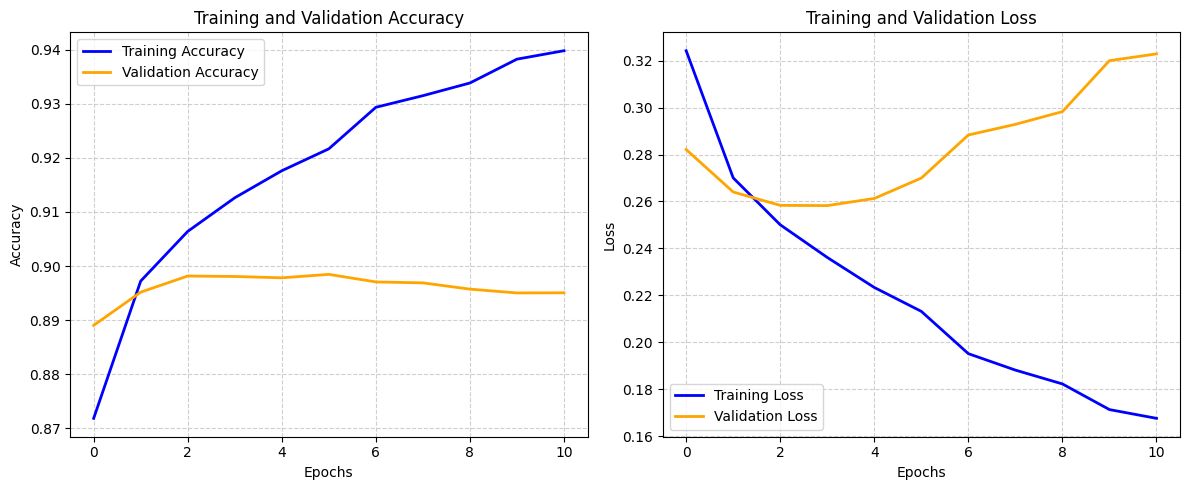

In [15]:
plt.figure(figsize=(12, 5))

#! Plot 1: Accuracy 
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy', color='blue', lw=2)
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', color='orange', lw=2)
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)


#! Plot 2: Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss', color='blue', lw=2)
plt.plot(history.history['val_loss'], label='Validation Loss', color='orange', lw=2)
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

In [16]:
loss, acc = model.evaluate(X_test_padded, y_test, verbose=0)
print("Validation accuracy of final model:", acc)

Validation accuracy of final model: 0.8980669379234314


In [17]:
# Get the probabilities
y_pred_probs = model.predict(X_test_padded)

# Convert probabilities to binary labels (0 or 1) using a 0.5 threshold
y_pred_labels = (y_pred_probs > 0.5).astype(int)

4718/4718 ━━━━━━━━━━━━━━━━━━━━ 31s 7ms/step


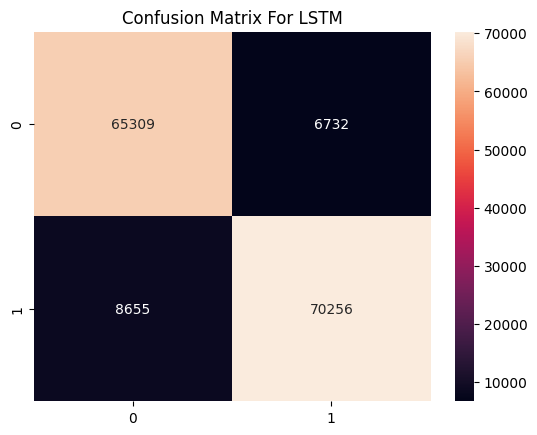

In [18]:
conf = confusion_matrix(y_true=y_test,y_pred=y_pred_labels)
sns.heatmap(conf,annot=True,fmt="1.0f")
plt.title("Confusion Matrix For LSTM")
plt.show()

In [19]:
y_test_labels = np.argmax(y_pred_probs, axis=1)

print(classification_report(y_test, y_pred_labels, zero_division=0))

              precision    recall  f1-score   support

           0       0.88      0.91      0.89     72041
           1       0.91      0.89      0.90     78911

    accuracy                           0.90    150952
   macro avg       0.90      0.90      0.90    150952
weighted avg       0.90      0.90      0.90    150952

